# Entrenamiento en Modelo de Regresión Lógistica

## 1 . Carga de Datos e Importaciones

### Importaciones

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import optuna
import joblib
from dotenv import load_dotenv
import os
import requests

### Configuración para que se cree en la carpeta models en la raiz

In [67]:
carpeta_notebooks = Path.cwd()
raiz_proyecto = carpeta_notebooks.parent
carpeta_models = raiz_proyecto / "models"
carpeta_models.mkdir(parents=True, exist_ok=True)

#print(f"📁 Raíz detectada: {raiz_proyecto}")
#print(f"💾 Carpeta de destino del modelo: {carpeta_models}\n")

### Cargar el dataset

In [68]:
load_dotenv()
URL_BACKEND_INTERSHIPS = os.getenv('URL_BACKEND_INTERSHIPS') 

In [69]:
def get_interships():
    try:
        response = requests.get(URL_BACKEND_INTERSHIPS)
        if response.status_code == 200:
            return response.json()
        else:
            print(f'Error al obtener los datos: {response.status_code} - {response.text}')
            return None
    except Exception as e:
        print(f'Error con la conexión a la API de Intership Selection: {e}')
        return None

In [70]:
try:
    df = pd.DataFrame(get_interships())
    df_raw = df.copy()
    print("Datos cargados exitosamente")
except Exception as e:
    print(f'Error al obtener los datos')

Datos cargados exitosamente


### Identificar columnas booleanas del dataframe original y transformarlas a enteros (0 y 1)

In [71]:
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

print(f"Columnas booleanas transformadas con éxito a 0 y 1: {bool_cols}")

Columnas booleanas transformadas con éxito a 0 y 1: ['placement_training', 'extracurricular']


## 2. Separación de Variables y Pipeline de Preprocesamiento

In [72]:
variables_seleccionadas = [
    'interview_score', 'skills_score', 'communication_score', 'coding_test_score',
    'projects_count', 'soft_skills_score', 'certifications_count', 'resume_score',
    'internships_done', 'extracurricular', 'consistency_score', 'placement_training',
    'cgpa', 'github_score'
]

X = df[variables_seleccionadas]
y = df['selected']

### Identificar columnas por tipo

In [73]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

### División estratificada 80/20

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Preprocesar datos para la fase de exploración con Optuna

In [76]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 3. Fase de Exploración con Optuna

In [77]:
# Listas para guardar la historia de los experimentos y analizarlos manualmente
historial_experimentos = []

In [78]:
def objective(trial):
    # Probar un rango amplio de la fuerza de regularización C
    C_value = trial.suggest_float('C', 1e-4, 10.0, log=True)

    # Crear y entrenar el modelo
    model = LogisticRegression(
        C=C_value,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_proc, y_train)

    # Calcular accuracy en train y test
    train_acc = accuracy_score(y_train, model.predict(X_train_proc))
    test_acc = accuracy_score(y_test, model.predict(X_test_proc))

    # Calcular porcentaje de overfitting
    overfitting = (train_acc - test_acc) * 100

    # Guardar resultados del experimento
    historial_experimentos.append({
        'trial_number': trial.number,
        'C': C_value,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'overfitting_porcentaje': overfitting,
        'valido_por_norma': overfitting <= 5.0
    })

    # Penalizar modelos con overfitting superior al 5 %
    if overfitting > 5.0:
        return 0.0

    # Maximizar accuracy en test
    return test_acc

### Ejecutar el estudio de exploración (25 combinaciones)

In [79]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

## 4. Entrenamiento del Modelo Definitivo

In [80]:
mejores_parametros = study.best_params
print(f"🥇 Hiperparámetro óptimo seleccionado: {mejores_parametros}")

🥇 Hiperparámetro óptimo seleccionado: {'C': 0.0007302921836789043}


### Construir el pipeline final unificado

In [81]:
pipeline_lr_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**mejores_parametros, max_iter=1000, random_state=42))
])

### Entrenar el pipeline completo con los datos originales

In [82]:
pipeline_lr_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['interview_score','skills_score','communication_score',..., 'placement_training','cgpa','github_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

### Generar predicciones y probabilidades


In [83]:
y_pred_val = pipeline_lr_final.predict(X_test)
y_pred_proba = pipeline_lr_final.predict_proba(X_test)[:, 1]

In [84]:
final_train_acc = accuracy_score(y_train, pipeline_lr_final.predict(X_train))
final_test_acc = accuracy_score(y_test, y_pred_val)
final_overfitting = (final_train_acc - final_test_acc) * 100

In [85]:
print("\n📊 --- MÉTRICAS FINALES ---")
print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Test Accuracy:  {final_test_acc:.4f}")
print(f"Overfitting:    {final_overfitting:.2f}%")


📊 --- MÉTRICAS FINALES ---
Train Accuracy: 0.7374
Test Accuracy:  0.7375
Overfitting:    -0.01%


## 5. Análisis Visual de Errores (Matriz de Confusión y Curva ROC)

In [86]:
cm = confusion_matrix(y_test, y_pred_val, normalize='true')
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

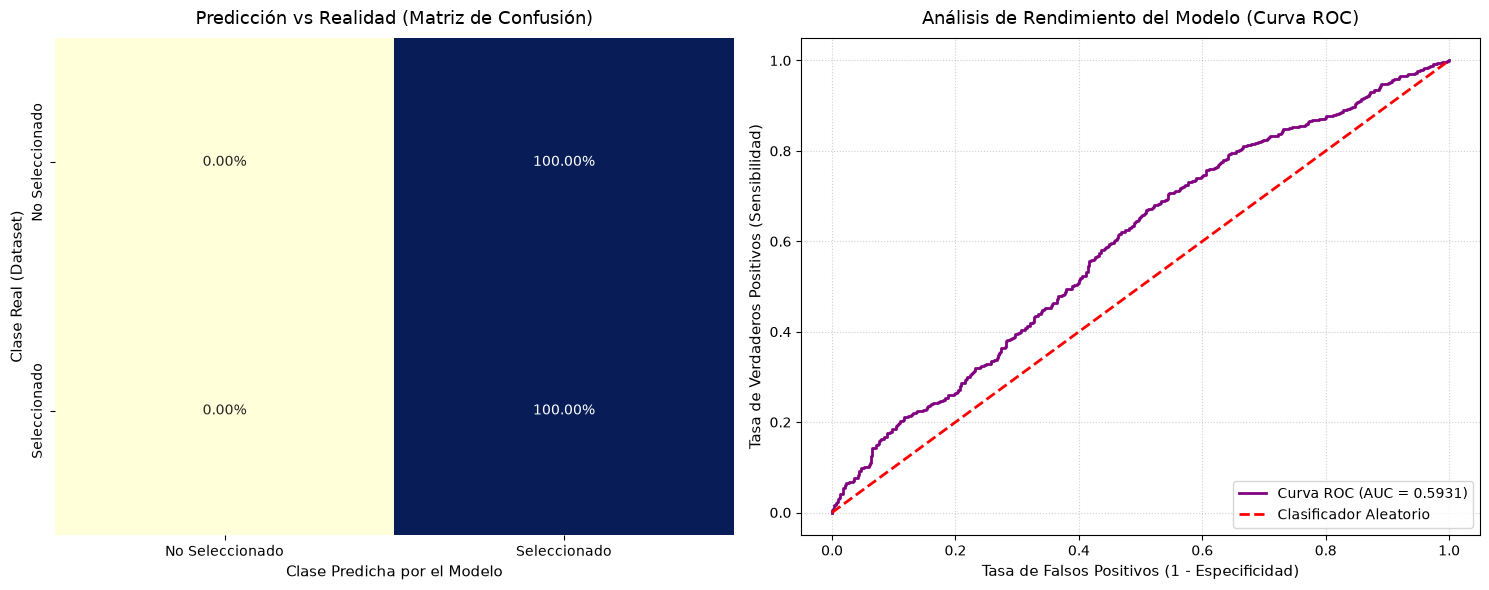

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

### Gráfico 1: Matriz de Confusión
sns.heatmap(cm, annot=True, fmt=".2%", cmap='YlGnBu', ax=axes[0], cbar=False,
            xticklabels=['No Seleccionado', 'Seleccionado'], 
            yticklabels=['No Seleccionado', 'Seleccionado'])
axes[0].set_title('Predicción vs Realidad (Matriz de Confusión)', fontsize=13, pad=10)
axes[0].set_xlabel('Clase Predicha por el Modelo', fontsize=11)
axes[0].set_ylabel('Clase Real (Dataset)', fontsize=11)

# Gráfico 2: Curva ROC
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Clasificador Aleatorio')
axes[1].set_title('Análisis de Rendimiento del Modelo (Curva ROC)', fontsize=13, pad=10)
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Análisis de Importancia de Variables (Permutation Importance)

### Extraer el modelo y el preprocesador del pipeline final calibrado

In [88]:
preprocessor_final = pipeline_lr_final.named_steps['preprocessor']
modelo_final = pipeline_lr_final.named_steps['classifier']

### Obtener los coeficientes del modelo de regresión logística

In [89]:
coeficientes = modelo_final.coef_[0]

### Obtener los nombres de las columnas numéricas de forma dinámica

In [90]:
num_features = preprocessor_final.transformers_[0][2]

### Obtener los nombres de las columnas categóricas/booleanas procesadas por el OneHotEncoder

In [91]:
cat_transformer = preprocessor_final.transformers_[1][1]
cat_features_input = preprocessor_final.transformers_[1][2]

### Si hay variables categóricas en las seleccionadas, extraemos sus nombres transformados

In [92]:
if len(cat_features_input) > 0:
    cat_features_encoded = cat_transformer.get_feature_names_out(cat_features_input)
    all_features = list(num_features) + list(cat_features_encoded)
else:
    all_features = list(num_features)

### Crear el DataFrame con los resultados

In [93]:
importances_df = pd.DataFrame({
    'Variable': all_features,
    'Coeficiente (Importancia)': coeficientes,
    'Importancia Absoluta': abs(coeficientes)
})

### Ordenar por importancia absoluta

In [94]:
importances_df = importances_df.sort_values(by='Importancia Absoluta', ascending=False)

### Crear la gráfica de barras para el informe técnico

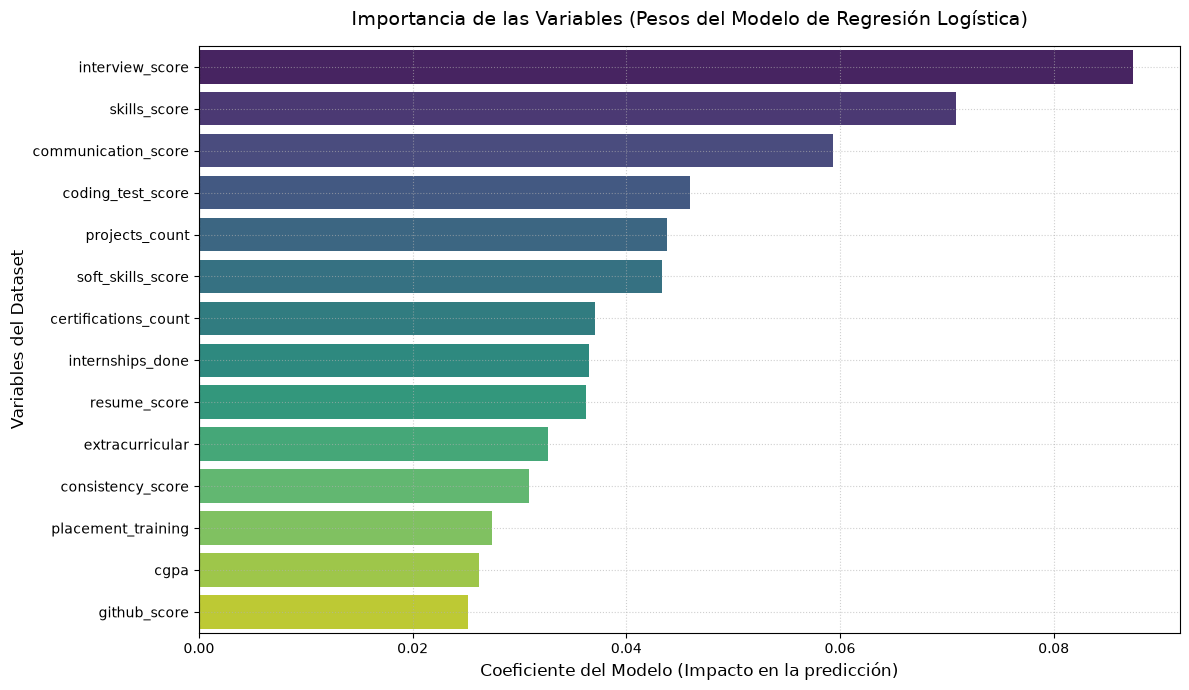

In [95]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Coeficiente (Importancia)',
    y='Variable',
    hue='Variable',
    data=importances_df,
    palette="viridis",
    legend=False
)

plt.title('Importancia de las Variables (Pesos del Modelo de Regresión Logística)', fontsize=14, pad=15)
plt.xlabel('Coeficiente del Modelo (Impacto en la predicción)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Línea guía en el 0
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Mostrar el Top de variables por texto estructurado

In [96]:
print("\n📋 --- RANKING DE IMPORTANCIA DE VARIABLES DE NEGOCIO ---")
print(importances_df.to_string(index=False))


📋 --- RANKING DE IMPORTANCIA DE VARIABLES DE NEGOCIO ---
            Variable  Coeficiente (Importancia)  Importancia Absoluta
     interview_score                   0.087447              0.087447
        skills_score                   0.070817              0.070817
 communication_score                   0.059383              0.059383
   coding_test_score                   0.045937              0.045937
      projects_count                   0.043844              0.043844
   soft_skills_score                   0.043301              0.043301
certifications_count                   0.037109              0.037109
    internships_done                   0.036523              0.036523
        resume_score                   0.036240              0.036240
     extracurricular                   0.032669              0.032669
   consistency_score                   0.030906              0.030906
  placement_training                   0.027468              0.027468
                cgpa            

## 7. Almacenamiento del Modelo (.pkl)

In [97]:
filename = carpeta_models / "logistic_regression.pkl"
joblib.dump(pipeline_lr_final, filename)
print(f"\n💾 ¡Modelo final calibrado y guardado con éxito en: '{filename}'!")


💾 ¡Modelo final calibrado y guardado con éxito en: 'c:\Users\Flor\Desktop\Programacion\DA-project-classification-Grupo2\models\logistic_regression.pkl'!
